# Resampling

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://raw.githubusercontent.com/AllenDowney/ElementsOfDataScience/v1/utils.py')

import utils

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ElementsOfDataScience/blob/v1/resampling_example_gun.ipynb).

## Support for Gun Control

In Chapter 10 we used data from the General Social Survey, specifically a variable called `gunlaw`, to describe support for a gun control law as a function of age, sex, and years of education.
Now let's come back to that dataset and see how the responses have changed over time.
Instructions for downloading the data are in the notebook for this chapter.

In [2]:
download('https://github.com/AllenDowney/ElementsOfDataScience/' +
         'raw/v1/data/gss_extract_2022.hdf');

We can load the dataset like this.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gss = pd.read_hdf('gss_extract_2022.hdf', 'gss')

The column named `gunlaw` records responses to the question "Would you favor or oppose a law which would require a person to obtain a police permit before he or she could buy a gun?"
The response code `1` means yes; `2` means no.  It will be easier to work with this variable if we recode it so `0` means no.

In [4]:
gss['gunlaw'] = gss['gunlaw'].replace(2, 0)
gss['gunlaw'].value_counts()

gunlaw
1.0    36367
0.0    11940
Name: count, dtype: int64

For each year of the survey, we'll compute the number of respondents and the number who said they favor this law.
We can use `groupby` to group the respondents by year of interview and `agg` to compute two aggregation functions, `sum` and `count`.

In [5]:
grouped = gss.groupby('year')['gunlaw']
agg = grouped.agg(['sum', 'count'])
agg.head()

,sum,count
year,,
1972,1131.0,1562
1973,1099.0,1470
1974,1112.0,1459
1975,1096.0,1450
1976,1068.0,1472


The result is a `DataFrame` with two columns: `sum` is the number of respondents who said "yes"; `count` is the number of respondents who were asked the question.
In some years the question was not asked, so I'll use `drop` to remove those rows.

In [6]:
zero = (agg['count'] == 0)
labels = agg.index[zero]
agg.drop(labels, inplace=True)

In [7]:
# check that the results are consistent
assert (gss['gunlaw'].value_counts().sum() == agg['count'].sum())

Now we can plot the percentage of respondents who favor gun control (at least for this wording of the question) during each year.

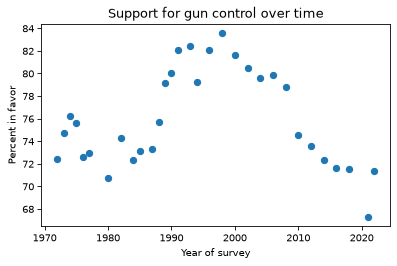

In [8]:
percent = agg['sum'] / agg['count'] * 100
percent.plot(style='o')

plt.xlabel('Year of survey')
plt.ylabel('Percent in favor')
plt.title('Support for gun control over time');

The results vary from year to year.  It is hard to tell how much of this variation is due to real changes in opinion, and how much is due to random sampling.
In the following exercise, you'll answer that question by computing confidence intervals for each of these data points.

**Exercise:** Write a loop that goes through the rows in `agg` and computes a confidence interval for each year.
You can use `itertuples` to iterate the rows, like this:

```
for year, k, n in agg.itertuples():
    print(year, k, n)
```

For each row, compute a 90% confidence interval and plot it as a vertical line.
Then plot the data points and label the axes.
The result should give you a sense of how much variation we expect to see from year to year due to random sampling.

You might want to use this version of `simulate_group`, which returns results as a percentage, rather than per 1000.

In [9]:
def simulate_group_percent(n, p):
    xs = np.random.random(size=n)
    k = np.sum(xs < p)
    return k / n * 100

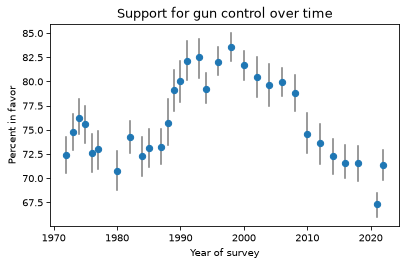

In [10]:
# Solution

for year, k, n in agg.itertuples():
    p = k / n
    t7 = [simulate_group_percent(n, p)
         for i in range(1000)]
    ci = np.percentile(t7, [5, 95])
    plt.plot([year, year], ci, 'gray')
    
percent.plot(style='o')

plt.xlabel('Year of survey')
plt.ylabel('Percent in favor')
plt.title('Support for gun control over time');

*Elements of Data Science*

Copyright 2021 [Allen B. Downey](https://allendowney.com)

License: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)